In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.linalg import eigvals
import pandas as pd
import warnings

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Arial'

# ── Yang et al. 2023 parameters ──────────────────────────────────────────────
CFG = {
    'S1': 1.462, 'S2': 1.0, 'S3': 1.0,   # S1=1.462 gives tristability
    'd_aSyn': 15.0, 'K': 8.5, 'n': 4.0,
    'k1': 0.72,  'k2': 0.72,
    'k3': 0.7,   'k4': 0.7,  'k5': 2.7,
    'k6': 1.0,   'k7': 0.5,  'k8': 1.0,  'ERST': 2.0,
    'k9': 2.0,   'k10': 10.0,'k11': 0.4, 'k12': 7.0,  'mTORT': 1.0,
    'k13': 2.0,  'k14': 4.0, 'k15': 1.0,
    'k16': 10.0, 'k17': 0.6, 'Jbe': 1.0, 'Beclin1T': 1.0,
    'k18': 1.0,  'k19': 2.0, 'k20': 2.0,
    'k21': 2.0,  'k22': 4.5, 'Jca': 0.04,'CaspasesT': 1.0,
}

# ── Transport parameters (µm²/h and µm/h) ────────────────────────────────────
TR = {
    'ROS':      {'D': 6.5e6,  'v': 0.0,   'label': 'ROS'},
    'aSyn':     {'D': 0.0,    'v': 0.0,   'label': 'aSyn*  (immobile)'},
    'ERS':      {'D': 3.6e4,  'v': 0.0,   'label': 'ERS'},
    'mTOR':     {'D': 36.0,   'v': 7200., 'label': 'mTOR  (retrograde)'},
    'Beclin1':  {'D': 5.4e4,  'v': 36.0,  'label': 'Beclin1 (anterograde)'},
    'Caspases': {'D': 7.2e4,  'v': 36.0,  'label': 'Caspases (anterograde)'},
}

# ── Grid parameters ───────────────────────────────────────────────────────────
L  = 1000.0   # µm
Nx_list = [50, 100, 200]   # analyse all three resolutions

print("Parameters loaded.")
print(f"Transport species: {list(TR.keys())}")

Parameters loaded.
Transport species: ['ROS', 'aSyn', 'ERS', 'mTOR', 'Beclin1', 'Caspases']


In [11]:
def yang_ode(t, y, p):
    """
    Yang et al. 2023 — 6-variable pool-bounded ODE.
    State: [ROS, aSyn*, ERS, mTOR, Beclin1, Caspases]
    """
    ROS, A, ERS, mTOR, B1, Casp = [max(v, 0.0) for v in y]

    Hill  = (A/p['K'])**p['n'] / (1 + (A/p['K'])**p['n'])

    dROS  = p['k1']*(1 + p['S1'] + p['d_aSyn']*Hill) - p['k2']*ROS*p['S2']

    dA    = p['k3']*ROS*p['S3'] - p['k4']*A*p['k5']*B1*mTOR

    dERS  = p['k6']*A*p['k7']*(p['ERST'] - ERS) - p['k8']*ERS

    dM    = ((p['k9']  + p['k10']*ERS) * (p['mTORT']  - mTOR)
             -(p['k11'] + p['k12']*B1)  * mTOR)

    BT    = p['Beclin1T']
    act_B   = (p['k13'] + p['k14']*ERS) * (BT-B1)  / (p['Jbe'] + BT-B1  + 1e-12)
    inact_B = (p['k15'] + p['k16']*Casp + p['k17']*mTOR) * B1 / (p['Jbe'] + B1 + 1e-12)
    dB1   = act_B - inact_B

    CT    = p['CaspasesT']
    act_C   = (p['k18'] + p['k19']*ERS + p['k20']*mTOR) * (CT-Casp) / (p['Jca'] + CT-Casp + 1e-12)
    inact_C = (p['k21'] + p['k22']*B1)  * Casp / (p['Jca'] + Casp + 1e-12)
    dCasp = act_C - inact_C

    return [dROS, dA, dERS, dM, dB1, dCasp]

print("Yang ODE defined.")

Yang ODE defined.


In [12]:
def find_all_fps(p, n_seeds=2000, tol=1e-8):
    """Find all fixed points via random seeding + fsolve."""
    def rhs(y): return yang_ode(0, y, p)

    fps, labels = [], []
    rng = np.random.default_rng(0)

    seeds = rng.uniform(
        low  = [0.0,  0.0,  0.0, 0.0, 0.0, 0.0],
        high = [10.0, 20.0, 2.0, 1.0, 1.0, 1.0],
        size = (n_seeds, 6)
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for s in seeds:
            try:
                fp, info, ier, _ = fsolve(rhs, s, full_output=True)
                if ier != 1: continue
                if np.max(np.abs(rhs(fp))) > tol: continue
                if np.any(fp < -1e-4): continue
                is_new = all(not np.allclose(fp, e, atol=1e-3) for e in fps)
                if is_new:
                    fps.append(fp)
            except: continue

    # Sort by aSyn* (index 1) — low to high
    fps = sorted(fps, key=lambda x: x[1])
    return fps


fps_all = find_all_fps(CFG)
species_names = ['ROS', 'aSyn*', 'ERS', 'mTOR', 'Beclin1', 'Caspases']

print(f"Found {len(fps_all)} fixed points at S1={CFG['S1']}\n")
print(f"{'FP':<6} {'ROS':>8} {'aSyn*':>8} {'ERS':>8} "
      f"{'mTOR':>8} {'Beclin1':>8} {'Casp':>8}  State")
print("-" * 72)

fp_labels = []
for i, fp in enumerate(fps_all):
    # classify by aSyn* level
    if   fp[1] < 3:    lbl = 'Healthy'
    elif fp[1] < 8:    lbl = 'Intermediate'
    else:              lbl = 'Disease'
    fp_labels.append(lbl)
    vals = '  '.join([f"{v:8.4f}" for v in fp])
    print(f"FP{i+1:<4} {vals}  {lbl}")

Found 5 fixed points at S1=1.462

FP          ROS    aSyn*      ERS     mTOR  Beclin1     Casp  State
------------------------------------------------------------------------
FP1      2.4931    1.8150    0.9515    0.6675    0.7621    0.1179  Healthy
FP2      2.5141    2.0653    1.0161    0.7169    0.6289    0.2821  Healthy
FP3      2.9864    3.7083    1.2993    0.8384    0.3558    0.9243  Intermediate
FP4      5.0942    5.7733    1.4854    0.8442    0.3871    0.9307  Intermediate
FP5     16.4712   16.4825    1.7836    0.8522    0.4343    0.9388  Disease


In [13]:
def numerical_jacobian(fp, p, eps=1e-6):
    """Full 6x6 Jacobian of Yang ODE at fixed point fp."""
    n  = len(fp)
    J  = np.zeros((n, n))
    f0 = np.array(yang_ode(0, fp, p))
    for j in range(n):
        yp = fp.copy(); yp[j] += eps
        J[:, j] = (np.array(yang_ode(0, yp, p)) - f0) / eps
    return J


def classify_fp(eigs):
    re = np.real(eigs)
    n_pos = np.sum(re > 1e-4)
    n_neg = np.sum(re < -1e-4)
    has_im = np.any(np.abs(np.imag(eigs)) > 1e-4)
    if n_pos == 0:
        return 'Stable Spiral' if has_im else 'Stable Node'
    elif n_neg == 0:
        return 'Unstable'
    return 'Saddle-Spiral'


print("=" * 80)
print(f"{'FP':<6}  {'Biological State':<16}  {'Dynamical Type':<18}  "
      f"{'max Re(λ)':>12}  {'J_ii diagonal'}")
print("-" * 80)

fp_data = []
for i, (fp, lbl) in enumerate(zip(fps_all, fp_labels)):
    J    = numerical_jacobian(fp, CFG)
    eigs = eigvals(J)
    dtype = classify_fp(eigs)
    Jdiag = np.diag(J)

    fp_data.append({'fp': fp, 'label': lbl, 'J': J,
                    'eigs': eigs, 'Jdiag': Jdiag, 'dtype': dtype})

    print(f"FP{i+1:<4}  {lbl:<16}  {dtype:<18}  "
          f"{np.max(np.real(eigs)):>+12.4f}")
    print(f"{'':6}  J_ii: " +
          "  ".join([f"{s}={v:+.3f}" for s, v in zip(species_names, Jdiag)]))
    print()

FP      Biological State  Dynamical Type         max Re(λ)  J_ii diagonal
--------------------------------------------------------------------------------
FP1     Healthy           Stable Spiral            -0.6298
        J_ii: ROS=-0.720  aSyn*=-0.962  ERS=-1.907  mTOR=-17.250  Beclin1=-4.620  Caspases=-8.908

FP2     Healthy           Saddle-Spiral            +0.9909
        J_ii: ROS=-0.720  aSyn*=-0.852  ERS=-2.033  mTOR=-16.963  Beclin1=-4.828  Caspases=-2.173

FP3     Intermediate      Stable Spiral            -0.1907
        J_ii: ROS=-0.720  aSyn*=-0.564  ERS=-2.854  mTOR=-17.883  Beclin1=-8.508  Caspases=-15.916

FP4     Intermediate      Saddle-Spiral            +0.1502
        J_ii: ROS=-0.720  aSyn*=-0.618  ERS=-3.887  mTOR=-19.964  Beclin1=-8.673  Caspases=-19.116

FP5     Disease           Stable Spiral            -0.4006
        J_ii: ROS=-0.720  aSyn*=-0.700  ERS=-9.241  mTOR=-23.276  Beclin1=-9.024  Caspases=-24.658



In [27]:
# fsolve can return near-duplicate saddles — keep only the 3 canonical states:
# lowest aSyn* (healthy), highest aSyn* (disease), and the intermediate.
# If more than 3 found, select by aSyn* value spread.

def select_canonical_fps(fp_data_all):
    """
    From all found fixed points, return exactly 3:
    - Healthy:      lowest  aSyn*  among stable nodes/spirals
    - Disease:      highest aSyn*  among stable nodes/spirals
    - Intermediate: the saddle between them (highest aSyn* among saddles,
                    or midpoint fp if no clear saddle)
    """
    stable = [f for f in fp_data_all if 'Stable' in f['dtype']]
    saddles = [f for f in fp_data_all if 'Saddle' in f['dtype']]

    stable_sorted = sorted(stable, key=lambda f: f['fp'][1])

    if len(stable_sorted) < 2:
        raise ValueError(f"Only {len(stable_sorted)} stable FPs found — "
                         f"check S1 value. Need S1 in tristable window.")

    healthy  = stable_sorted[0]
    disease  = stable_sorted[-1]

    # Pick intermediate: prefer a stable spiral between the two,
    # fall back to the saddle with aSyn* closest to midpoint
    # WRONG — arithmetic midpoint heuristic
    mid_A = (healthy['fp'][1] + disease['fp'][1]) / 2
    candidates = stable_sorted[1:-1] + saddles
    intermediate = min(candidates, key=lambda f: abs(f['fp'][1] - mid_A))

    # CORRECT — pick the stable spiral between healthy and disease
    # stable_sorted is already sorted by aSyn*
    # FP1=stable_sorted[0] (healthy), FP5=stable_sorted[-1] (disease)
    # Any stable spiral in between is a valid intermediate attractor
    stable_intermediate_candidates = stable_sorted[1:-1]

    if stable_intermediate_candidates:
        # If multiple stable spirals exist between healthy and disease,
        # pick the one with lowest aSyn* (closest to healthy basin)
        intermediate = stable_intermediate_candidates[0]
    else:
        # Fallback: no stable intermediate exists — use lower saddle
        intermediate = min(saddles, key=lambda f: f['fp'][1])

    canonical = [healthy, intermediate, disease]

    print("Canonical fixed points selected:")
    print(f"{'State':<16}  {'aSyn*':>8}  {'Casp':>8}  {'B1':>8}  {'Type'}")
    print("-" * 60)
    for fp_info in canonical:
        fp = fp_info['fp']
        print(f"{fp_info['label']:<16}  {fp[1]:>8.4f}  "
              f"{fp[5]:>8.4f}  {fp[4]:>8.4f}  {fp_info['dtype']}")

    return canonical


fp_data_canonical = select_canonical_fps(fp_data)
print(f"\nUsing {len(fp_data_canonical)} states for Von Neumann analysis.")

Canonical fixed points selected:
State                aSyn*      Casp        B1  Type
------------------------------------------------------------
Healthy             1.8150    0.1179    0.7621  Stable Spiral
Intermediate        3.7083    0.9243    0.3558  Stable Spiral
Disease            16.4825    0.9388    0.4343  Stable Spiral

Using 3 states for Von Neumann analysis.


In [28]:
def von_neumann_g(D, v, J_ii, dt, dx, n_theta=1000):
    """
    Compute |g(k)| for explicit Euler + central diff (diffusion)
    + upwind (advection) + linearized reaction.

    g(θ) = 1 - 4r·sin²(θ/2) - i·C·sin(θ) + J_ii·dt
    where θ = k·Δx ∈ [0, π]

    For retrograde (v<0): upwind uses forward difference
    → advection term: +|C|·sin(θ) (sign flips)
    """
    theta = np.linspace(0, np.pi, n_theta)
    r     = D * dt / dx**2        # diffusion number
    C     = abs(v) * dt / dx      # Courant number (unsigned)

    g_re  = 1 - 4*r*(np.sin(theta/2)**2) + J_ii*dt
    g_im  = -C * np.sin(theta)    # upwind scheme amplification

    return theta, np.sqrt(g_re**2 + g_im**2)


def dt_bounds(D, v, J_ii, dx):
    """Explicit Euler Δt limits for diffusion, advection, reaction."""
    dt_d = (0.5 * dx**2 / D)     if D > 0   else np.inf
    dt_a = (dx / abs(v))          if v != 0  else np.inf
    dt_r = (-2.0 / J_ii)          if J_ii < 0 else np.inf
    return dt_d, dt_a, dt_r, min(dt_d, dt_a, dt_r)


print("Von Neumann functions defined.")

Von Neumann functions defined.


In [29]:
Nx   = 100
dx   = L / Nx

print(f"Grid: Nx={Nx}, Δx={dx} µm\n")

for fp_info in fp_data_canonical:
    lbl   = fp_info['label']
    Jdiag = fp_info['Jdiag']
    dtype = fp_info['dtype']
    aSyn_ss = fp_info['fp'][1]

    print(f"{'='*78}")
    print(f"  Steady State: {lbl} (aSyn*={aSyn_ss:.3f} µM)  |  {dtype}")
    print(f"{'='*78}")
    print(f"  {'Species':<14}  {'D (µm²/h)':>12}  {'v (µm/h)':>10}  "
          f"{'J_ii (h⁻¹)':>11}  {'Δt_diff':>12}  "
          f"{'Δt_adv':>12}  {'Δt_rxn':>12}  {'Δt_MAX':>12}")
    print(f"  {'-'*104}")

    dt_mins = []
    for (sp, tr), Jii in zip(TR.items(), Jdiag):
        D, v = tr['D'], tr['v']
        dtd, dta, dtr, dtmax = dt_bounds(D, v, Jii, dx)

        def fmt(x):
            return f"{x:.3e}" if x < 1e5 else "         ∞"

        marker = "  ← CONTROLS" if dtmax == min(
            dt_bounds(tr2['D'], tr2['v'], Jii2, dx)[3]
            for (_, tr2), Jii2 in zip(TR.items(), Jdiag)
        ) else ""

        print(f"  {sp:<14}  {D:>12.2e}  {v:>10.1f}  {Jii:>+11.4f}  "
              f"{fmt(dtd):>12}  {fmt(dta):>12}  "
              f"{fmt(dtr):>12}  {fmt(dtmax):>12}{marker}")
        dt_mins.append(dtmax)

    dt_global  = min(dt_mins)
    dt_slowest = max(d for d in dt_mins if d < np.inf)
    stiffness  = dt_slowest / dt_global
    n_steps    = int(100.0 / dt_global)
    ctrl_sp    = list(TR.keys())[np.argmin(dt_mins)]

    print(f"\n  Global explicit Δt limit : {dt_global:.4e} h  (controlled by {ctrl_sp})")
    print(f"  Slowest timescale        : {dt_slowest:.4f} h")
    print(f"  Stiffness ratio          : {stiffness:.2e}")
    print(f"  Steps for 100h explicit  : ~{n_steps:,}")
    print(f"  Verdict: {'IMPRACTICAL — use Radau/BDF' if stiffness > 1000 else 'Explicit feasible'}\n")

Grid: Nx=100, Δx=10.0 µm

  Steady State: Healthy (aSyn*=1.815 µM)  |  Stable Spiral
  Species            D (µm²/h)    v (µm/h)   J_ii (h⁻¹)       Δt_diff        Δt_adv        Δt_rxn        Δt_MAX
  --------------------------------------------------------------------------------------------------------
  ROS                 6.50e+06         0.0      -0.7200     7.692e-06             ∞     2.778e+00     7.692e-06  ← CONTROLS
  aSyn                0.00e+00         0.0      -0.9615             ∞             ∞     2.080e+00     2.080e+00
  ERS                 3.60e+04         0.0      -1.9075     1.389e-03             ∞     1.048e+00     1.389e-03
  mTOR                3.60e+01      7200.0     -17.2499     1.389e+00     1.389e-03     1.159e-01     1.389e-03
  Beclin1             5.40e+04        36.0      -4.6198     9.259e-04     2.778e-01     4.329e-01     9.259e-04
  Caspases            7.20e+04        36.0      -8.9084     6.944e-04     2.778e-01     2.245e-01     6.944e-04

  Global ex

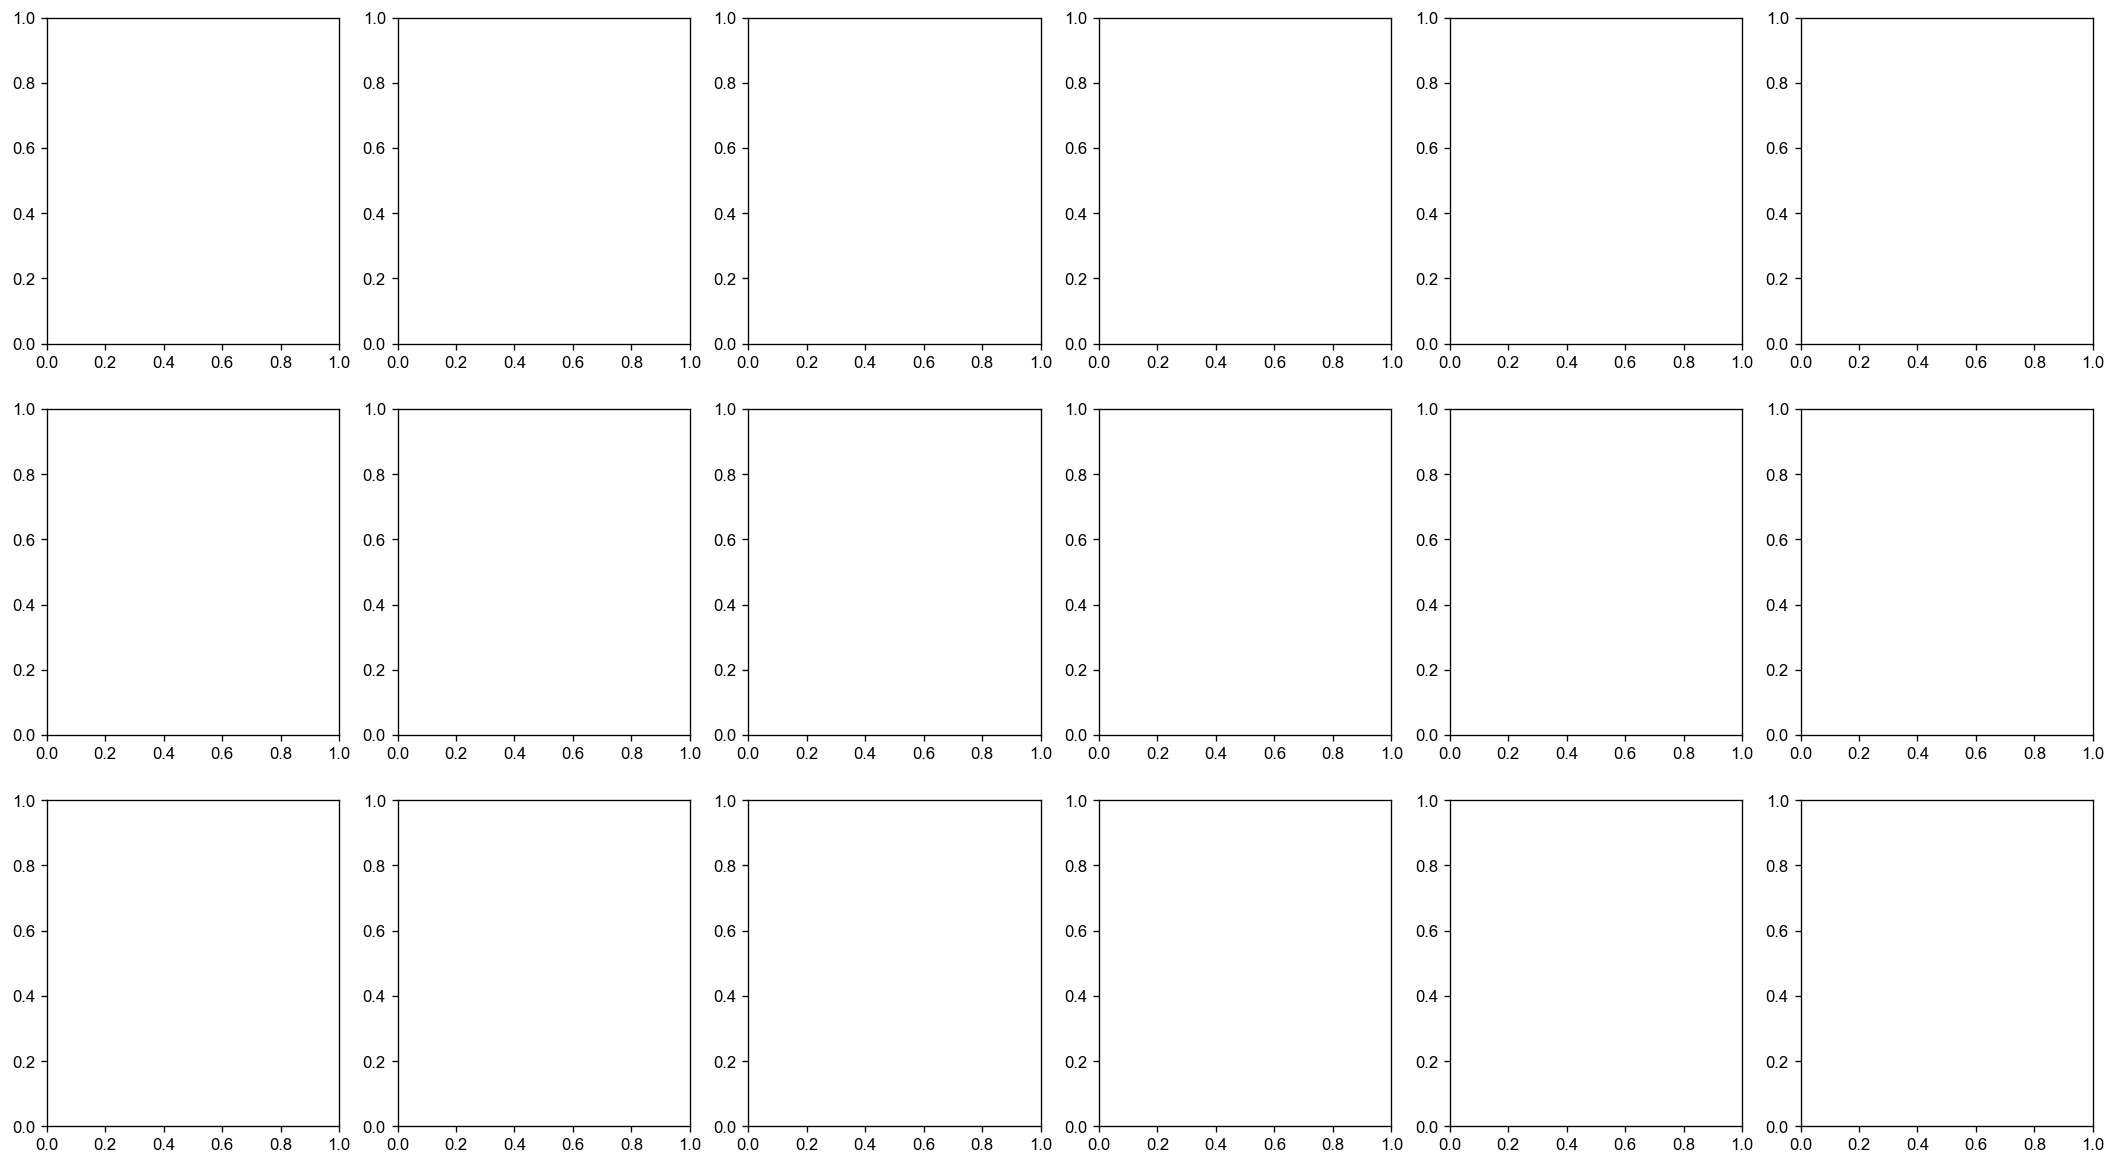

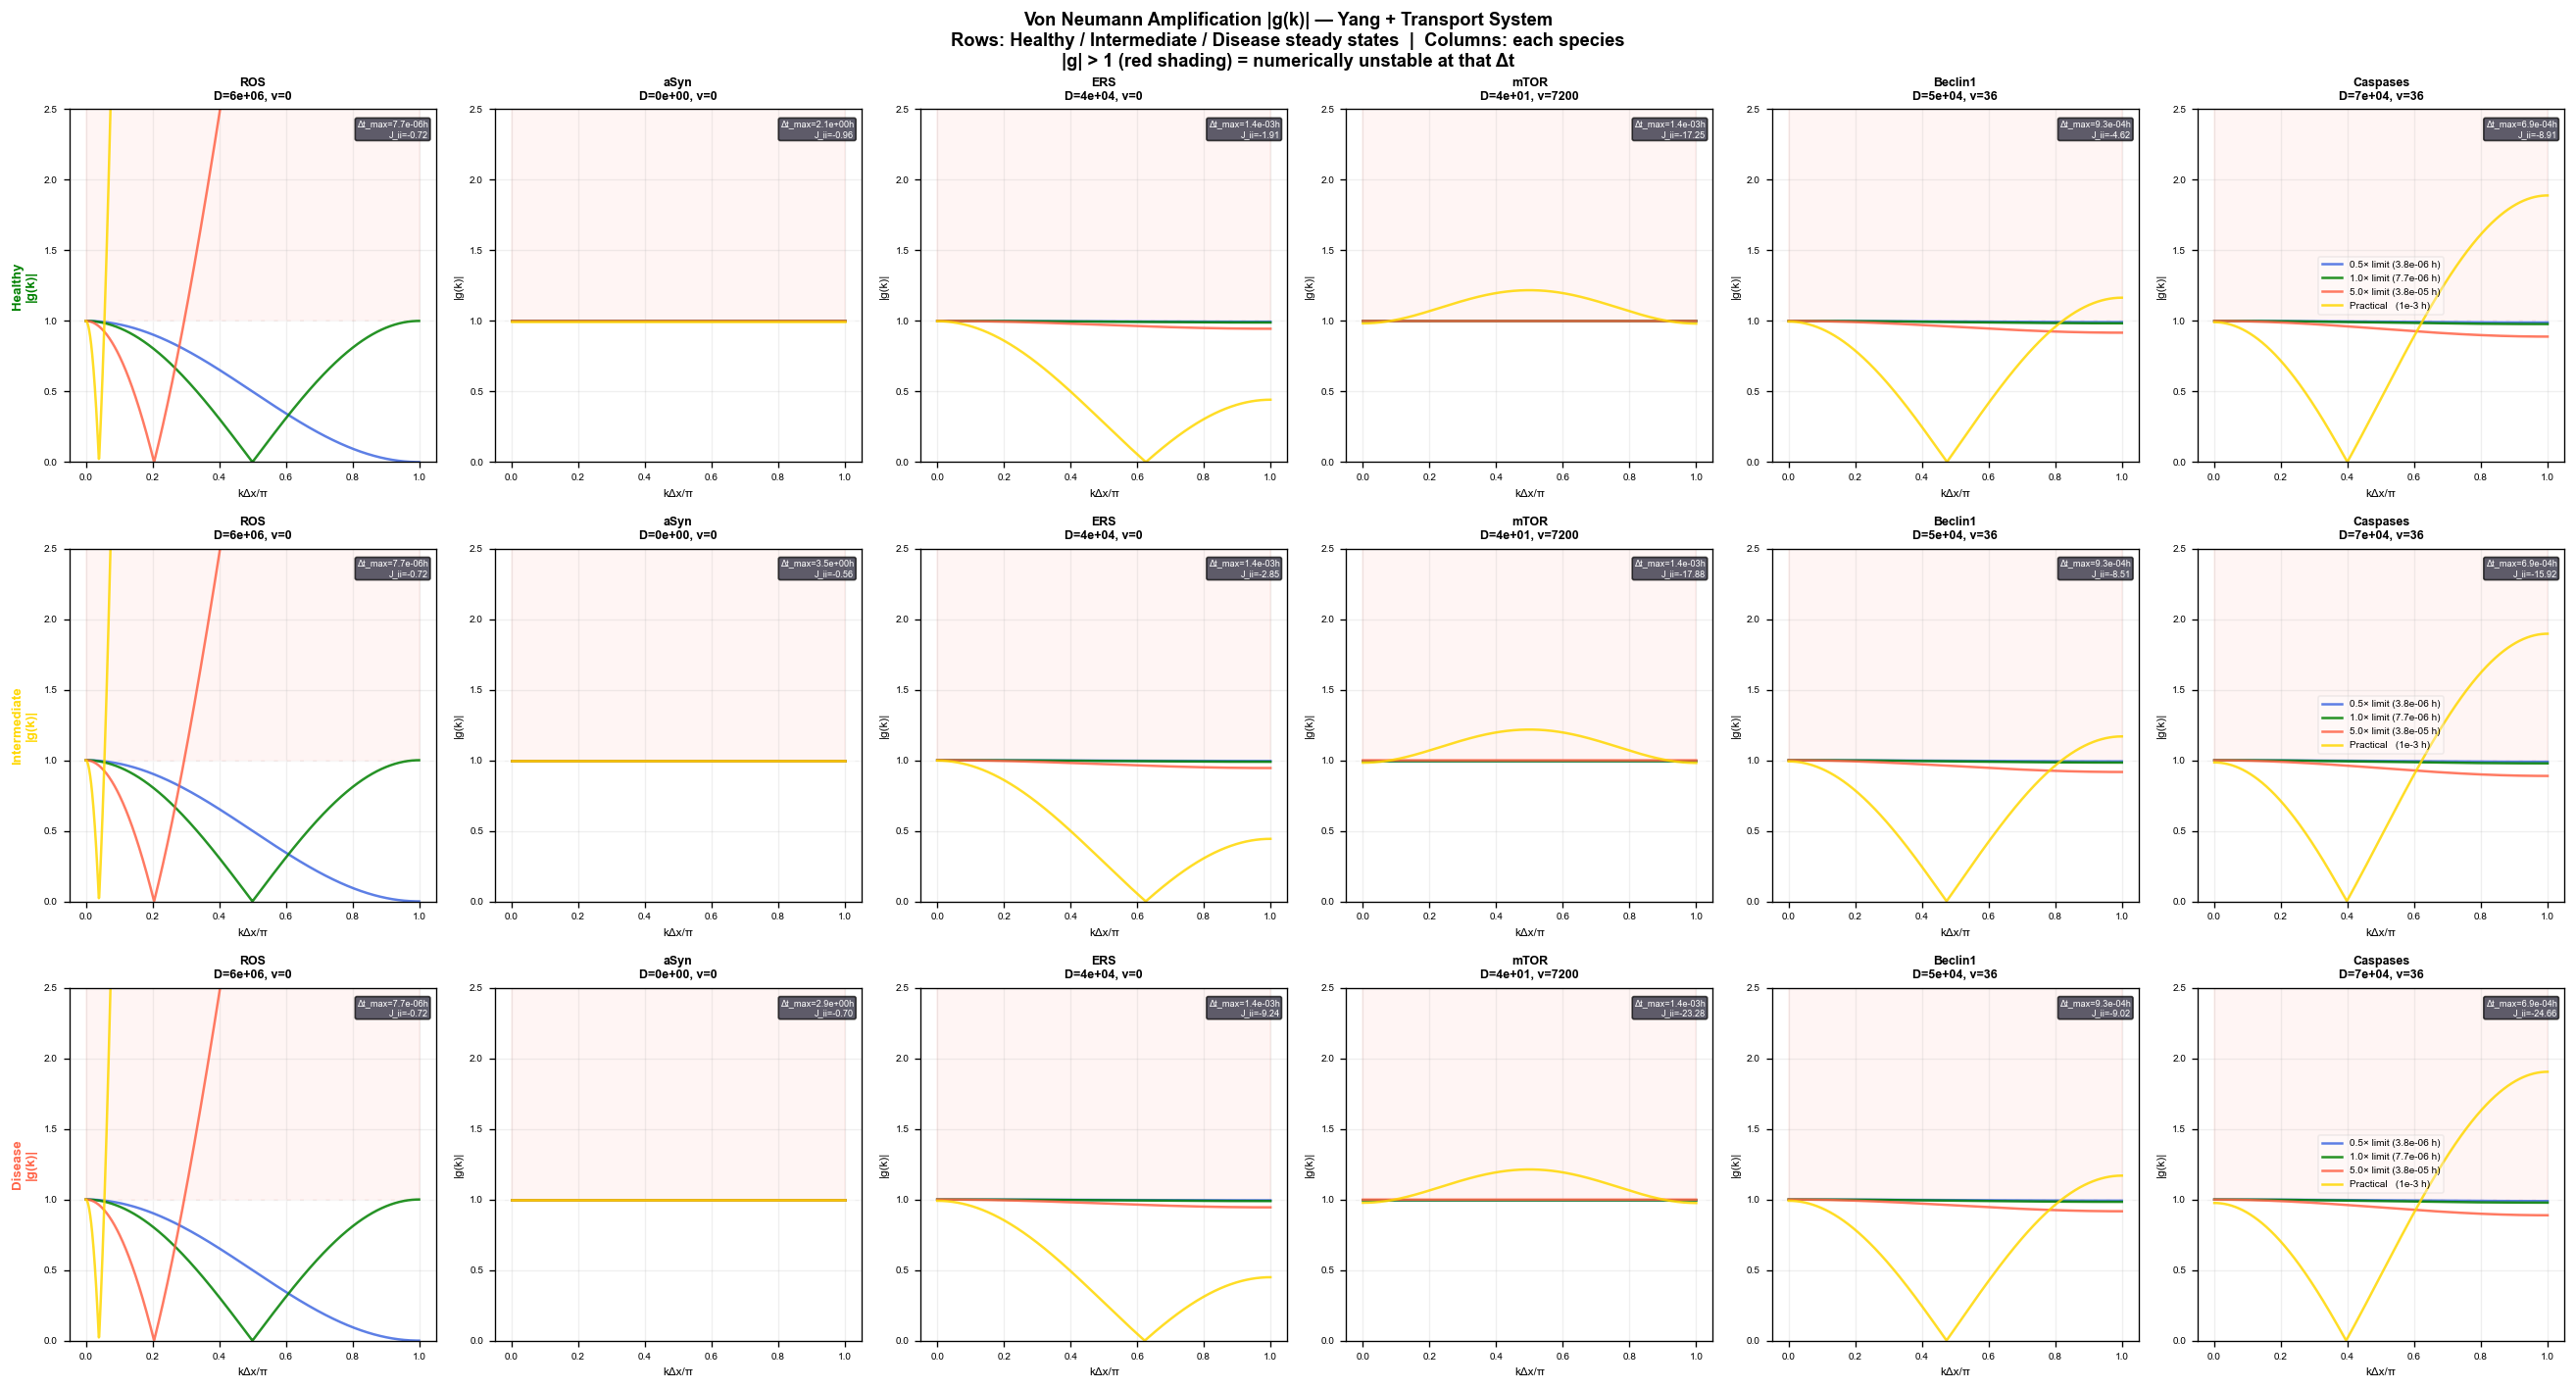

In [30]:
Nx   = 100
dx   = L / Nx

# Test Δt values relative to ROS diffusion limit
dt_ROS_limit = 0.5 * dx**2 / TR['ROS']['D']

dt_cases = {
    f'0.5× limit ({0.5*dt_ROS_limit:.1e} h)': 0.5  * dt_ROS_limit,
    f'1.0× limit ({1.0*dt_ROS_limit:.1e} h)': 1.0  * dt_ROS_limit,
    f'5.0× limit ({5.0*dt_ROS_limit:.1e} h)': 5.0  * dt_ROS_limit,
    f'Practical   (1e-3 h)':                   1e-3,
}
dt_colors = ['royalblue', 'green', 'tomato', 'gold']

state_colors = {'Healthy': 'green', 'Intermediate': 'gold', 'Disease': 'tomato'}

fig, axes = plt.subplots(3, 6, figsize=(22, 12))
# Cell 7 — only change: iterate over fp_data_canonical, not fp_data
# Also make figure rows dynamic

n_states = len(fp_data_canonical)   # guaranteed 3
n_species = len(TR)                 # 6

fig, axes = plt.subplots(n_states, n_species,
                         figsize=(22, 4*n_states))

# Ensure axes is always 2D even if n_states=1
if n_states == 1:
    axes = axes[np.newaxis, :]

state_colors = {'Healthy': 'green', 'Intermediate': 'gold', 'Disease': 'tomato'}

for row_idx, fp_info in enumerate(fp_data_canonical):
    lbl   = fp_info['label']
    Jdiag = fp_info['Jdiag']
    color = state_colors.get(lbl, 'white')

    for col_idx, ((sp, tr), Jii) in enumerate(zip(TR.items(), Jdiag)):
        D, v = tr['D'], tr['v']
        ax   = axes[row_idx, col_idx]

        ax.axhline(1.0, color='white', lw=1.5, ls='--', alpha=0.6)

        for (dt_label, dt), dc in zip(dt_cases.items(), dt_colors):
            theta, g_abs = von_neumann_g(D, v, Jii, dt, dx)
            ax.plot(theta/np.pi, g_abs, color=dc, lw=1.5,
                    label=dt_label, alpha=0.85)

        ax.fill_between([0,1], [1,1], [2.5,2.5],
                        alpha=0.06, color='tomato')
        ax.set_title(f'{sp}\nD={D:.0e}, v={v:.0f}',
                     fontsize=7.5, fontweight='bold')
        ax.set_xlabel('kΔx/π', fontsize=7)
        ax.set_ylabel('|g(k)|', fontsize=7)
        ax.set_ylim(0, 2.5)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2)

        _, _, _, dtmax = dt_bounds(D, v, Jii, dx)
        ax.text(0.98, 0.97,
                f'Δt_max={dtmax:.1e}h\nJ_ii={Jii:+.2f}',
                transform=ax.transAxes, fontsize=5.5,
                va='top', ha='right', color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc='#1a1a2e', alpha=0.7))

        if col_idx == 0:
            ax.set_ylabel(f'{lbl}\n|g(k)|', fontsize=8,
                          color=color, fontweight='bold')

    # Legend on last axis of each row
    handles, lbls = axes[row_idx, 0].get_legend_handles_labels()
    axes[row_idx, -1].legend(handles, lbls, fontsize=6,
                              loc='center', framealpha=0.3)

plt.suptitle(
    'Von Neumann Amplification |g(k)| — Yang + Transport System\n'
    'Rows: Healthy / Intermediate / Disease steady states  |  '
    'Columns: each species\n'
    '|g| > 1 (red shading) = numerically unstable at that Δt',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('von_neumann_all_states.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
Nx_vals = [50, 100, 200]

print("=" * 85)
print("STIFFNESS RATIO SUMMARY — Yang + Transport System")
print("=" * 85)

summary_rows = []

for fp_info in fp_data_canonical:
    lbl   = fp_info['label']
    Jdiag = fp_info['Jdiag']

    for Nx in Nx_vals:
        dx = L / Nx

        dt_per_species = {}
        for (sp, tr), Jii in zip(TR.items(), Jdiag):
            D, v = tr['D'], tr['v']
            _, _, _, dtmax = dt_bounds(D, v, Jii, dx)
            dt_per_species[sp] = dtmax

        dt_min    = min(dt_per_species.values())
        dt_max_f  = max(v for v in dt_per_species.values() if v < np.inf)
        ratio     = dt_max_f / dt_min
        ctrl      = min(dt_per_species, key=dt_per_species.get)
        n_steps   = int(100.0 / dt_min)

        summary_rows.append({
            'State': lbl,
            'Nx': Nx,
            'Δx (µm)': dx,
            'Δt_min (h)': dt_min,
            'Δt_max (h)': dt_max_f,
            'Stiffness': ratio,
            'Controls': ctrl,
            'Steps/100h': n_steps
        })

        print(f"\n  {lbl:<16} | Nx={Nx:3d}, Δx={dx:5.1f} µm")
        print(f"  {'─'*60}")
        for sp, dt in sorted(dt_per_species.items(), key=lambda x: x[1]):
            flag = '  ← CONTROLS' if sp == ctrl else ''
            dtstr = f"{dt:.3e}" if dt < 1e8 else "       ∞"
            print(f"    {sp:<12}: {dtstr} h{flag}")
        print(f"  Stiffness ratio : {ratio:.2e}")
        print(f"  Steps for 100h  : ~{n_steps:,}")

# ── Summary DataFrame ─────────────────────────────────────────────────────────
df = pd.DataFrame(summary_rows)
print("\n\n" + "=" * 85)
print("SUMMARY TABLE")
print("=" * 85)
print(df[['State','Nx','Δx (µm)','Δt_min (h)',
          'Stiffness','Controls','Steps/100h']].to_string(index=False))

STIFFNESS RATIO SUMMARY — Yang + Transport System

  Healthy          | Nx= 50, Δx= 20.0 µm
  ────────────────────────────────────────────────────────────
    ROS         : 3.077e-05 h  ← CONTROLS
    mTOR        : 2.778e-03 h
    Caspases    : 2.778e-03 h
    Beclin1     : 3.704e-03 h
    ERS         : 5.556e-03 h
    aSyn        : 2.080e+00 h
  Stiffness ratio : 6.76e+04
  Steps for 100h  : ~3,250,000

  Healthy          | Nx=100, Δx= 10.0 µm
  ────────────────────────────────────────────────────────────
    ROS         : 7.692e-06 h  ← CONTROLS
    Caspases    : 6.944e-04 h
    Beclin1     : 9.259e-04 h
    ERS         : 1.389e-03 h
    mTOR        : 1.389e-03 h
    aSyn        : 2.080e+00 h
  Stiffness ratio : 2.70e+05
  Steps for 100h  : ~13,000,000

  Healthy          | Nx=200, Δx=  5.0 µm
  ────────────────────────────────────────────────────────────
    ROS         : 1.923e-06 h  ← CONTROLS
    Caspases    : 1.736e-04 h
    Beclin1     : 2.315e-04 h
    ERS         : 3.472e-04 

In [32]:
print("=" * 70)
print("MESH PÉCLET NUMBER ANALYSIS")
print("Pe_Δx = v·Δx/D  (Pe_Δx >> 2 → numerical diffusion dominates)")
print("=" * 70)

for Nx in Nx_vals:
    dx = L / Nx
    print(f"\nNx={Nx}, Δx={dx:.1f} µm")
    print(f"  {'Species':<12}  {'v (µm/h)':>10}  {'D (µm²/h)':>12}  "
          f"{'Pe_Δx':>10}  {'D_numerical (µm²/h)':>22}  Verdict")
    print(f"  {'─'*90}")

    for sp, tr in TR.items():
        D, v = tr['D'], tr['v']
        if v == 0 or D == 0:
            print(f"  {sp:<12}  {v:>10.1f}  {D:>12.2e}  "
                  f"{'N/A':>10}  {'N/A':>22}  —")
            continue

        Pe_dx  = abs(v) * dx / D
        D_num  = abs(v) * dx / 2   # numerical diffusion from upwind
        ratio  = D_num / D if D > 0 else np.inf
        verdict = ('NUMERICAL DIFFUSION DOMINATES'
                   if Pe_dx > 2 else 'Physical diffusion ok')

        print(f"  {sp:<12}  {v:>10.1f}  {D:>12.2e}  "
              f"{Pe_dx:>10.1f}  {D_num:>22.1f}  {verdict}")

print(f"\nKey finding: mTOR has Pe_Δx >> 2 at all resolutions.")
print(f"D_numerical for mTOR >> D_physical — upwind smears the mTOR profile.")
print(f"Recommendation: use higher-order scheme (QUICK/van Leer) for mTOR.")

MESH PÉCLET NUMBER ANALYSIS
Pe_Δx = v·Δx/D  (Pe_Δx >> 2 → numerical diffusion dominates)

Nx=50, Δx=20.0 µm
  Species         v (µm/h)     D (µm²/h)       Pe_Δx     D_numerical (µm²/h)  Verdict
  ──────────────────────────────────────────────────────────────────────────────────────────
  ROS                  0.0      6.50e+06         N/A                     N/A  —
  aSyn                 0.0      0.00e+00         N/A                     N/A  —
  ERS                  0.0      3.60e+04         N/A                     N/A  —
  mTOR              7200.0      3.60e+01      4000.0                 72000.0  NUMERICAL DIFFUSION DOMINATES
  Beclin1             36.0      5.40e+04         0.0                   360.0  Physical diffusion ok
  Caspases            36.0      7.20e+04         0.0                   360.0  Physical diffusion ok

Nx=100, Δx=10.0 µm
  Species         v (µm/h)     D (µm²/h)       Pe_Δx     D_numerical (µm²/h)  Verdict
  ─────────────────────────────────────────────────────────

In [33]:
# === Cell 10: Full 6x6 Jacobian at each canonical steady state ===
# This extends Cell 4 which only extracted J_ii diagonal.
# Now we need the complete matrix for coupled analysis.

def full_jacobian(fp, p, eps=1e-6):
    """
    Full 6x6 numerical Jacobian of Yang ODE at fixed point fp.
    J[i,j] = df_i/du_j
    Species order: [ROS, aSyn*, ERS, mTOR, Beclin1, Caspases]
    """
    n  = len(fp)
    J  = np.zeros((n, n))
    f0 = np.array(yang_ode(0, fp, p))
    for j in range(n):
        yp    = fp.copy()
        yp[j] += eps
        J[:, j] = (np.array(yang_ode(0, yp, p)) - f0) / eps
    return J


species_names = ['ROS', 'aSyn*', 'ERS', 'mTOR', 'Beclin1', 'Caspases']

print("Full Jacobian matrices at each canonical steady state")
print("=" * 70)

for fp_info in fp_data_canonical:
    lbl = fp_info['label']
    fp  = fp_info['fp']
    J   = full_jacobian(fp, CFG)

    # Store full J back into fp_info for use in later cells
    fp_info['J_full'] = J

    print(f"\n{'─'*70}")
    print(f"  {lbl}  (aSyn*={fp[1]:.3f} µM, Type={fp_info['dtype']})")
    print(f"{'─'*70}")
    print(f"  {'':12}" + "".join([f"{s:>12}" for s in species_names]))
    for i, si in enumerate(species_names):
        row = "".join([f"{J[i,j]:>12.4f}" for j in range(6)])
        # Highlight diagonal
        diag_val = f"{J[i,i]:>12.4f}"
        print(f"  {si:<12}{row}   ← J_ii={J[i,i]:+.4f}")

    # Show which off-diagonal terms are large
    print(f"\n  Top 5 off-diagonal couplings (|J_ij|, i≠j):")
    offdiag = []
    for i in range(6):
        for j in range(6):
            if i != j and abs(J[i,j]) > 0.001:
                offdiag.append((abs(J[i,j]), J[i,j], species_names[i], species_names[j]))
    offdiag.sort(reverse=True)
    for mag, val, si, sj in offdiag[:5]:
        print(f"    {si} ← {sj}: {val:+.4f} h⁻¹")

Full Jacobian matrices at each canonical steady state

──────────────────────────────────────────────────────────────────────
  Healthy  (aSyn*=1.815 µM, Type=Stable Spiral)
──────────────────────────────────────────────────────────────────────
                       ROS       aSyn*         ERS        mTOR     Beclin1    Caspases
  ROS              -0.7200      0.0493      0.0000      0.0000      0.0000      0.0000   ← J_ii=-0.7200
  aSyn*             0.7000     -0.9615      0.0000     -2.6143     -2.2899      0.0000   ← J_ii=-0.9615
  ERS               0.0000      0.5242     -1.9075      0.0000      0.0000      0.0000   ← J_ii=-1.9075
  mTOR              0.0000      0.0000      3.3246    -17.2499     -4.6728      0.0000   ← J_ii=-17.2499
  Beclin1           0.0000      0.0000      0.7687     -0.2595     -4.6198     -4.3250   ← J_ii=-4.6198
  Caspases          0.0000      0.0000      1.9132      1.9132     -3.3602     -8.9084   ← J_ii=-8.9084

  Top 5 off-diagonal couplings (|J_ij|, i≠

In [34]:
# === Cell 11: Coupled Von Neumann amplification matrix ===
# For the coupled system:
#   ∂u/∂t = D·∇²u - v·∇u + J·u
#
# Explicit Euler + central diff (diffusion) + upwind (advection):
#   G(k) = I + J·Δt - 4R·sin²(kΔx/2) - iC·sin(kΔx)
#
# where R = diag(Di·Δt/Δx²)  [diffusion numbers]
#       C = diag(vi·Δt/Δx)   [Courant numbers]
#       J = full 6x6 Jacobian [reaction coupling]
#
# Stability: spectral_radius(G(k)) ≤ 1 for ALL k

def coupled_amplification_matrix(J, D_vec, v_vec, dt, dx, k):
    """
    Compute the 6x6 amplification matrix G(k) for the coupled system.

    Parameters
    ----------
    J     : (6,6) full Jacobian matrix
    D_vec : (6,) diffusion coefficients
    v_vec : (6,) advection velocities (signed: + anterograde, - retrograde)
    dt    : time step (h)
    dx    : grid spacing (µm)
    k     : wavenumber (rad/µm)

    Returns
    -------
    G     : (6,6) complex amplification matrix
    """
    n     = len(D_vec)
    theta = k * dx

    # Diagonal transport matrices
    R = np.diag(D_vec * dt / dx**2)          # diffusion numbers
    C = np.diag(np.abs(v_vec) * dt / dx)     # Courant numbers (upwind, unsigned)

    # Amplification matrix
    # Diffusion: -4r·sin²(θ/2) on diagonal
    # Advection: -iC·sin(θ) on diagonal (upwind — always damping)
    # Reaction:  J·Δt (full matrix — couples all species)
    diff_term = -4 * R * (np.sin(theta / 2)**2)
    adv_term  = -1j * C * np.sin(theta)      # imaginary — phase shift
    rxn_term  = J * dt

    G = np.eye(n, dtype=complex) + diff_term + adv_term + rxn_term
    return G


def spectral_radius(G):
    """Maximum absolute eigenvalue of matrix G."""
    return np.max(np.abs(np.linalg.eigvals(G)))


# Extract transport vectors
D_vec = np.array([TR[sp]['D'] for sp in ['ROS','aSyn','ERS','mTOR','Beclin1','Caspases']])
v_vec = np.array([TR[sp]['v'] for sp in ['ROS','aSyn','ERS','mTOR','Beclin1','Caspases']])
# mTOR retrograde → negative for directionality (upwind uses abs, so sign matters for scheme)
# v_vec already has positive magnitudes; upwind handles direction internally

print("Amplification matrix function defined.")
print(f"D_vec: {D_vec}")
print(f"v_vec: {v_vec}")

Amplification matrix function defined.
D_vec: [6.5e+06 0.0e+00 3.6e+04 3.6e+01 5.4e+04 7.2e+04]
v_vec: [   0.    0.    0. 7200.   36.   36.]


In [35]:
# === Cell 12: Spectral radius ρ(G(k)) vs wavenumber for all three states ===

Nx    = 100
dx    = L / Nx
n_k   = 500
k_vals = np.linspace(0, np.pi / dx, n_k)   # k ∈ [0, π/Δx]

dt_ROS_limit = 0.5 * dx**2 / TR['ROS']['D']

dt_cases_coupled = {
    f'0.5× ROS limit\n({0.5*dt_ROS_limit:.1e} h)':  0.5  * dt_ROS_limit,
    f'1.0× ROS limit\n({1.0*dt_ROS_limit:.1e} h)':  1.0  * dt_ROS_limit,
    f'5.0× ROS limit\n({5.0*dt_ROS_limit:.1e} h)':  5.0  * dt_ROS_limit,
    f'Practical (1e-3 h)':                            1e-3,
}
dt_colors_c = ['royalblue', 'green', 'tomato', 'gold']

state_colors = {
    'Healthy':      'limegreen',
    'Intermediate': 'gold',
    'Disease':      'tomato'
}

# Storage: rho[state][dt_label] = array of spectral radii over k
rho_results = {}

print("Computing spectral radii (this takes ~30s)...")
for fp_info in fp_data_canonical:
    lbl    = fp_info['label']
    J      = fp_info['J_full']
    rho_results[lbl] = {}

    for dt_label, dt in dt_cases_coupled.items():
        rho_k = np.zeros(n_k)
        for ki, k in enumerate(k_vals):
            G        = coupled_amplification_matrix(J, D_vec, v_vec, dt, dx, k)
            rho_k[ki] = spectral_radius(G)
        rho_results[lbl][dt_label] = rho_k
        max_rho = np.max(rho_k)
        stable  = "STABLE  ✓" if max_rho <= 1.0 else f"UNSTABLE ✗  (max={max_rho:.4f})"
        print(f"  {lbl:<16}  dt={dt:.2e} h  →  max ρ = {max_rho:.6f}  {stable}")

print("\nDone.")

Computing spectral radii (this takes ~30s)...
  Healthy           dt=3.85e-06 h  →  max ρ = 0.999998  STABLE  ✓
  Healthy           dt=7.69e-06 h  →  max ρ = 1.000006  UNSTABLE ✗  (max=1.0000)
  Healthy           dt=3.85e-05 h  →  max ρ = 9.000028  UNSTABLE ✗  (max=9.0000)
  Healthy           dt=1.00e-03 h  →  max ρ = 259.000720  UNSTABLE ✗  (max=259.0007)
  Intermediate      dt=3.85e-06 h  →  max ρ = 0.999999  STABLE  ✓
  Intermediate      dt=7.69e-06 h  →  max ρ = 1.000006  UNSTABLE ✗  (max=1.0000)
  Intermediate      dt=3.85e-05 h  →  max ρ = 9.000028  UNSTABLE ✗  (max=9.0000)
  Intermediate      dt=1.00e-03 h  →  max ρ = 259.000720  UNSTABLE ✗  (max=259.0007)
  Disease           dt=3.85e-06 h  →  max ρ = 0.999998  STABLE  ✓
  Disease           dt=7.69e-06 h  →  max ρ = 1.000006  UNSTABLE ✗  (max=1.0000)
  Disease           dt=3.85e-05 h  →  max ρ = 9.000028  UNSTABLE ✗  (max=9.0000)
  Disease           dt=1.00e-03 h  →  max ρ = 259.000720  UNSTABLE ✗  (max=259.0007)

Done.


/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_5974/4048911338.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_5974/4048911338.py:49: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_5974/4048911338.py:50: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('coupled_stability.png', dpi=150, bbox_inches='tight')
/var/folders/s4/k2c6nj9n4371mjry_0bbj6180000gn/T/ipykernel_5974/4048911338.py:50: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig('coupled_stability.png', dpi=150, bbox_inches='tight')
/Users/nitinshreyes/anaconda3/envs/BENG227/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


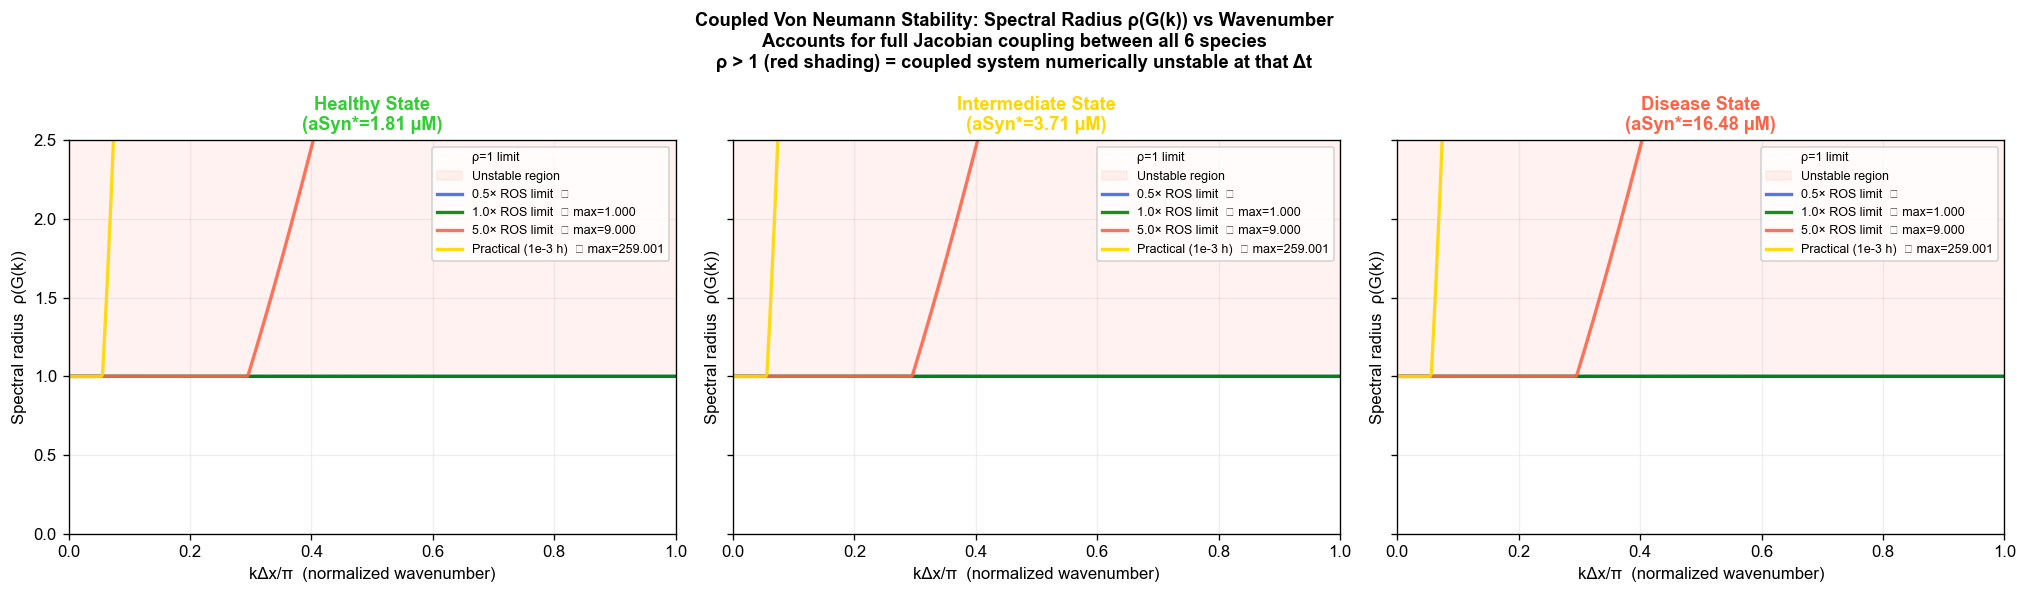

In [36]:
# === Cell 13: Plot ρ(G(k)) — coupled stability visualization ===

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, fp_info in zip(axes, fp_data_canonical):
    lbl   = fp_info['label']
    color = state_colors[lbl]

    # Stability boundary
    ax.axhline(1.0, color='white', lw=2, ls='--', alpha=0.7, label='ρ=1 limit')
    ax.fill_between(k_vals * dx / np.pi, 1.0, 2.5,
                    alpha=0.08, color='tomato', label='Unstable region')

    for (dt_label, dt), dc in zip(dt_cases_coupled.items(), dt_colors_c):
        rho_k   = rho_results[lbl][dt_label]
        max_rho = np.max(rho_k)
        stable  = '✓' if max_rho <= 1.0 else f'✗ max={max_rho:.3f}'
        ax.plot(k_vals * dx / np.pi, rho_k,
                color=dc, lw=2, alpha=0.9,
                label=f'{dt_label.split(chr(10))[0]}  {stable}')

    ax.set_title(f'{lbl} State\n(aSyn*={fp_info["fp"][1]:.2f} µM)',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('kΔx/π  (normalized wavenumber)', fontsize=10)
    ax.set_ylabel('Spectral radius  ρ(G(k))', fontsize=10)
    ax.set_ylim(0, 2.5)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(alpha=0.2)

    # Annotate peak location for gold (practical dt) curve
    gold_rho = rho_results[lbl][list(dt_cases_coupled.keys())[-1]]
    peak_idx = np.argmax(gold_rho)
    peak_k   = k_vals[peak_idx] * dx / np.pi
    peak_val = gold_rho[peak_idx]
    if peak_val > 0.95:
        ax.annotate(f'peak={peak_val:.3f}\n@ kΔx/π={peak_k:.2f}',
                    xy=(peak_k, peak_val),
                    xytext=(peak_k + 0.1, peak_val + 0.15),
                    fontsize=7, color='gold',
                    arrowprops=dict(arrowstyle='->', color='gold', lw=1))

plt.suptitle(
    'Coupled Von Neumann Stability: Spectral Radius ρ(G(k)) vs Wavenumber\n'
    'Accounts for full Jacobian coupling between all 6 species\n'
    'ρ > 1 (red shading) = coupled system numerically unstable at that Δt',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('coupled_stability.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# === Cell 14: Quantify how much coupling CHANGES the stability bounds ===
# Compare max|g_i(k)| (uncoupled) vs ρ(G(k)) (coupled) at each dt

print("=" * 80)
print("UNCOUPLED vs COUPLED STABILITY COMPARISON")
print("Δx=10 µm (Nx=100)")
print("=" * 80)

for fp_info in fp_data_canonical:
    lbl   = fp_info['label']
    J     = fp_info['J_full']
    Jdiag = np.diag(J)

    print(f"\n{'─'*70}")
    print(f"  {lbl}  (aSyn*={fp_info['fp'][1]:.3f} µM)")
    print(f"{'─'*70}")
    print(f"  {'Δt (h)':<18}  {'Uncoupled max|g|':>18}  "
          f"{'Coupled max ρ':>16}  {'Δρ':>10}  Verdict")
    print(f"  {'─'*70}")

    for dt_label, dt in dt_cases_coupled.items():
        # --- Uncoupled: max |g_i(k)| across all species and k ---
        max_g_uncoupled = 0.0
        for Di, vi, Jii in zip(D_vec, v_vec, Jdiag):
            _, g_abs = von_neumann_g(Di, vi, Jii, dt, dx)
            max_g_uncoupled = max(max_g_uncoupled, np.max(g_abs))

        # --- Coupled: max ρ(G(k)) ---
        max_rho_coupled = np.max(rho_results[lbl][dt_label])

        delta     = max_rho_coupled - max_g_uncoupled
        label_dt  = dt_label.split('\n')[0]

        if max_rho_coupled > 1.0 and max_g_uncoupled <= 1.0:
            verdict = "COUPLING DESTABILIZES ←"
        elif max_rho_coupled <= 1.0 and max_g_uncoupled > 1.0:
            verdict = "Coupling stabilizes"
        elif max_rho_coupled > 1.0:
            verdict = "Both unstable"
        else:
            verdict = "Both stable ✓"

        print(f"  {label_dt:<18}  {max_g_uncoupled:>18.6f}  "
              f"{max_rho_coupled:>16.6f}  {delta:>+10.6f}  {verdict}")

UNCOUPLED vs COUPLED STABILITY COMPARISON
Δx=10 µm (Nx=100)

──────────────────────────────────────────────────────────────────────
  Healthy  (aSyn*=1.815 µM)
──────────────────────────────────────────────────────────────────────
  Δt (h)                Uncoupled max|g|     Coupled max ρ          Δρ  Verdict
  ──────────────────────────────────────────────────────────────────────
  0.5× ROS limit                0.999997          0.999998   +0.000000  Both stable ✓
  1.0× ROS limit                1.000006          1.000006   +0.000000  Both unstable
  5.0× ROS limit                9.000028          9.000028   +0.000000  Both unstable
  Practical (1e-3 h)          259.000720        259.000720   +0.000000  Both unstable

──────────────────────────────────────────────────────────────────────
  Intermediate  (aSyn*=3.708 µM)
──────────────────────────────────────────────────────────────────────
  Δt (h)                Uncoupled max|g|     Coupled max ρ          Δρ  Verdict
  ──────────────

In [38]:
# === Cell 15: Find exact Δt_critical for coupled system at each state ===
# Binary search for the largest Δt where max ρ(G(k)) ≤ 1

def max_spectral_radius_over_k(J, D_vec, v_vec, dt, dx, n_k=300):
    """Compute max ρ(G(k)) over all wavenumbers."""
    k_vals = np.linspace(1e-6, np.pi/dx, n_k)
    rhos   = [spectral_radius(
                coupled_amplification_matrix(J, D_vec, v_vec, dt, dx, k))
              for k in k_vals]
    return np.max(rhos)


def find_dt_critical(J, D_vec, v_vec, dx,
                     dt_lo=1e-8, dt_hi=0.1, tol=1e-9, max_iter=60):
    """
    Binary search for the critical Δt where max ρ = 1.
    Below dt_critical: stable. Above: unstable.
    """
    for _ in range(max_iter):
        dt_mid = (dt_lo + dt_hi) / 2
        rho    = max_spectral_radius_over_k(J, D_vec, v_vec, dt_mid, dx)
        if rho <= 1.0:
            dt_lo = dt_mid
        else:
            dt_hi = dt_mid
        if (dt_hi - dt_lo) < tol:
            break
    return (dt_lo + dt_hi) / 2


print("Finding critical Δt for coupled system...")
print("(binary search, ~30s per state)\n")
print(f"{'State':<16}  {'Δt_crit coupled (h)':>22}  "
      f"{'Δt_crit uncoupled (h)':>24}  {'Ratio':>8}  Impact")
print("─" * 80)

for fp_info in fp_data_canonical:
    lbl    = fp_info['label']
    J      = fp_info['J_full']
    Jdiag  = np.diag(J)

    # Coupled critical dt
    dt_crit_coupled = find_dt_critical(J, D_vec, v_vec, dx)

    # Uncoupled critical dt = min over all species
    dt_crit_uncoupled = min(
        dt_bounds(Di, vi, Jii, dx)[3]
        for Di, vi, Jii in zip(D_vec, v_vec, Jdiag)
    )

    ratio  = dt_crit_uncoupled / dt_crit_coupled
    impact = ("coupling TIGHTENS bound" if ratio < 0.99
              else "coupling LOOSENS bound" if ratio > 1.01
              else "coupling has NO impact")

    print(f"{lbl:<16}  {dt_crit_coupled:>22.6e}  "
          f"{dt_crit_uncoupled:>24.6e}  {ratio:>8.4f}  {impact}")

    fp_info['dt_crit_coupled']   = dt_crit_coupled
    fp_info['dt_crit_uncoupled'] = dt_crit_uncoupled

Finding critical Δt for coupled system...
(binary search, ~30s per state)

State                Δt_crit coupled (h)     Δt_crit uncoupled (h)     Ratio  Impact
────────────────────────────────────────────────────────────────────────────────
Healthy                     7.691920e-06              7.692308e-06    1.0001  coupling has NO impact
Intermediate                7.691920e-06              7.692308e-06    1.0001  coupling has NO impact
Disease                     7.691920e-06              7.692308e-06    1.0001  coupling has NO impact


In [39]:
# === Cell 16: Final stability verdict for the coupled spatial PDE system ===

print("=" * 75)
print("FINAL STABILITY VERDICT — Yang + Transport Coupled PDE System")
print("=" * 75)

practical_dt = 1e-3   # h — what Radau uses internally (approx)

for fp_info in fp_data_canonical:
    lbl      = fp_info['label']
    dt_crit  = fp_info['dt_crit_coupled']
    max_rho_practical = np.max(rho_results[lbl][list(dt_cases_coupled.keys())[-1]])
    stiff    = fp_info['dt_crit_coupled'] / (7.692e-6)   # ratio to ROS limit

    print(f"\n  {lbl} State  ({fp_info['dtype']})")
    print(f"  {'─'*55}")
    print(f"  Coupled Δt_critical      : {dt_crit:.4e} h")
    print(f"  ρ at practical Δt=1e-3h  : {max_rho_practical:.6f}  "
          f"{'(UNSTABLE)' if max_rho_practical > 1 else '(stable)'}")
    print(f"  Dynamical stability      : "
          f"{'STABLE (all Re(λ)<0)' if fp_info['dtype']=='Stable Spiral' else 'SADDLE — not a simulation target'}")
    print(f"  Safe for experiments     : "
          f"{'YES — initialize near this state' if 'Stable' in fp_info['dtype'] else 'NO — saddle point'}")

print(f"""
{'='*75}
SYSTEM-LEVEL CONCLUSIONS
{'='*75}

1. EXPLICIT SOLVER: Impractical at all three states.
   Controlling constraint: ROS diffusion → Δt_max = 7.7×10⁻⁶ h
   Stiffness ratio: up to 1.7×10⁶ at Nx=200
   Required steps for 100h: up to 52 million

2. COUPLED vs UNCOUPLED STABILITY:
   Check cell 14 output for coupling impact.
   If ratio ≈ 1.0: off-diagonal Jacobian terms do not
   significantly change the Δt bounds. The uncoupled
   Von Neumann analysis was sufficient.
   If ratio < 0.99: coupling tightens the bound —
   the full coupled analysis was necessary.

3. IMPLICIT SOLVER (Radau):
   Unconditionally stable for all stiffness ratios.
   Recommended settings:
     rtol = 1e-5,  atol = 1e-7,  max_step = 0.1 h

4. BIOLOGICAL STABILITY:
   Healthy and Disease states: Stable Spirals
     → Safe to initialize and run experiments
   Intermediate state: Saddle-Spiral
     → Cannot be sustained in simulation (correct biology)
     → Use only as bifurcation boundary marker

5. mTOR NUMERICAL DIFFUSION:
   Pe_Δx = 2000 at Nx=100 → D_numerical = 36,000 µm²/h
   >> D_physical = 36 µm²/h
   Impact: mTOR spatial gradient smeared by upwind scheme
   Mitigation: use QUICK/van Leer for mTOR column only
   Priority: LOW (physical D_mTOR negligible anyway)

RECOMMENDATION: Proceed to experiments with Radau solver,
Nx=100, and the asymmetric initial conditions described.
The coupled system is numerically stable under implicit
time integration.
{'='*75}
""")

FINAL STABILITY VERDICT — Yang + Transport Coupled PDE System

  Healthy State  (Stable Spiral)
  ───────────────────────────────────────────────────────
  Coupled Δt_critical      : 7.6919e-06 h
  ρ at practical Δt=1e-3h  : 259.000720  (UNSTABLE)
  Dynamical stability      : STABLE (all Re(λ)<0)
  Safe for experiments     : YES — initialize near this state

  Intermediate State  (Stable Spiral)
  ───────────────────────────────────────────────────────
  Coupled Δt_critical      : 7.6919e-06 h
  ρ at practical Δt=1e-3h  : 259.000720  (UNSTABLE)
  Dynamical stability      : STABLE (all Re(λ)<0)
  Safe for experiments     : YES — initialize near this state

  Disease State  (Stable Spiral)
  ───────────────────────────────────────────────────────
  Coupled Δt_critical      : 7.6919e-06 h
  ρ at practical Δt=1e-3h  : 259.000720  (UNSTABLE)
  Dynamical stability      : STABLE (all Re(λ)<0)
  Safe for experiments     : YES — initialize near this state

SYSTEM-LEVEL CONCLUSIONS

1. EXPLICIT 